# Lisbon Housing Baseline: Results and Interpretation

This standalone notebook loads the cleaned merged panel, reproduces the baseline models, displays diagnostics, and provides prompts for thesis interpretation.

## Scope
This is a Portugal-wide district-by-quarter descriptive baseline. National series are constant across districts in a quarter, so they cannot be estimated separately with quarter fixed effects. It is not causal evidence on Lisbon, immigration, foreign investment, or infrastructure.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from linearmodels.panel import PanelOLS, PooledOLS

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 1. Load cleaned merged data

The preferred file is `data/clean/district_quarter_full_dataset.csv`. The fallbacks support the equivalent dataset in other repository locations. No raw-data rebuilding is performed here.

In [3]:
def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the repository.')

ROOT = find_repo_root()
candidates = [
    ROOT / 'data' / 'clean' / 'district_quarter_full_dataset.csv',
    ROOT / 'data' / 'district_quarter_full_dataset.csv',
    ROOT / 'outputs' / 'district_quarter_panel_final.csv',
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('No cleaned merged panel found.')

raw = pd.read_csv(DATA_PATH)
print(f'Loaded {DATA_PATH.relative_to(ROOT)}: {raw.shape[0]:,} rows x {raw.shape[1]:,} columns')
display(raw.head())

Loaded data/clean/district_quarter_full_dataset.csv: 820 rows x 21 columns


,district,period,year,quarter,date,price_sqm_sale,price_sqm_rental,log_price_sale,price_growth_qoq,price_growth_yoy,ine_transaction_count_national,ine_transaction_value_thousands_national,ine_price_value_index_national,ine_volume_index_national,mortgage_rate_fixed_pct_national,fdi_realestate_transactions_meur_national,fdi_realestate_stock_meur_national,fdi_total_stock_meur_national,construction_cost_yoy_growth_pct_national,population_national,unemployment_rate_pct_regional
0,aveiro,1T2015,2015,1,2015-01-01,782.6667,3.7000,6.6627,NaN,NaN,"21,762.0000","2,662,680.0000",101.1939,96.1761,NaN,319.1200,"12,554.7900","125,514.7000",0.7000,"10,381,838.0000",14.2000
1,aveiro,2T2015,2015,2,2015-04-01,789.0000,3.7667,6.6708,0.0081,NaN,"20,614.0000","2,509,888.0000",100.6992,91.1025,NaN,297.1400,"12,851.9300","125,514.7000",0.8333,"10,381,838.0000",12.4000
2,aveiro,3T2015,2015,3,2015-07-01,825.0000,3.9333,6.7154,0.0456,NaN,"22,928.0000","2,697,752.0000",97.3128,101.3291,NaN,319.6800,"13,171.6200","125,514.7000",1.1333,"10,381,838.0000",12.3000
3,aveiro,4T2015,2015,4,2015-10-01,823.3333,3.9000,6.7134,-0.0020,NaN,"25,205.0000","3,071,762.0000",100.7941,111.3922,NaN,405.3400,"13,576.9600","125,514.7000",1.2000,"10,381,838.0000",12.5000
4,aveiro,1T2016,2016,1,2016-01-01,804.6667,4.0000,6.6904,-0.0227,0.0281,"24,926.0000","3,001,077.0000",99.5769,110.1592,NaN,434.9000,"14,011.8600","127,838.9200",1.3667,"10,356,516.0000",12.8000


## 2. Standardise and transform

The primary outcome is the natural log of asking sale price per square metre. Quarter-on-quarter and year-on-year log growth, a lagged outcome, and a time trend are recreated within each district.

In [4]:
panel = raw.rename(columns={
    'log_price_sale': 'log_price',
    'ine_volume_index_national': 'volume_index',
    'fdi_realestate_transactions_meur_national': 'fdi_real_estate_transactions_meur',
    'mortgage_rate_fixed_pct_national': 'mortgage_rate_fixed',
}).copy()

panel['date'] = pd.to_datetime(panel['date'])
panel['quarter'] = panel['date'].dt.to_period('Q').astype(str)
if 'log_price' not in panel.columns:
    panel['log_price'] = np.log(panel['price_sqm_sale'])

panel = panel.sort_values(['district', 'date']).reset_index(drop=True)
panel['price_growth_qoq'] = panel.groupby('district')['log_price'].diff()
panel['price_growth_yoy'] = panel.groupby('district')['log_price'].diff(4)
panel['log_price_lag1'] = panel.groupby('district')['log_price'].shift(1)
panel['t'] = panel['date'].rank(method='dense').astype(int) - 1
display(panel.head(8))

,district,period,year,quarter,date,price_sqm_sale,price_sqm_rental,log_price,price_growth_qoq,price_growth_yoy,ine_transaction_count_national,ine_transaction_value_thousands_national,ine_price_value_index_national,volume_index,mortgage_rate_fixed,fdi_real_estate_transactions_meur,fdi_realestate_stock_meur_national,fdi_total_stock_meur_national,construction_cost_yoy_growth_pct_national,population_national,unemployment_rate_pct_regional,log_price_lag1,t
0,aveiro,1T2015,2015,2015Q1,2015-01-01,782.6667,3.7000,6.6627,NaN,NaN,"21,762.0000","2,662,680.0000",101.1939,96.1761,NaN,319.1200,"12,554.7900","125,514.7000",0.7000,"10,381,838.0000",14.2000,NaN,0
1,aveiro,2T2015,2015,2015Q2,2015-04-01,789.0000,3.7667,6.6708,0.0081,NaN,"20,614.0000","2,509,888.0000",100.6992,91.1025,NaN,297.1400,"12,851.9300","125,514.7000",0.8333,"10,381,838.0000",12.4000,6.6627,1
2,aveiro,3T2015,2015,2015Q3,2015-07-01,825.0000,3.9333,6.7154,0.0446,NaN,"22,928.0000","2,697,752.0000",97.3128,101.3291,NaN,319.6800,"13,171.6200","125,514.7000",1.1333,"10,381,838.0000",12.3000,6.6708,2
3,aveiro,4T2015,2015,2015Q4,2015-10-01,823.3333,3.9000,6.7134,-0.0020,NaN,"25,205.0000","3,071,762.0000",100.7941,111.3922,NaN,405.3400,"13,576.9600","125,514.7000",1.2000,"10,381,838.0000",12.5000,6.7154,3
4,aveiro,1T2016,2016,2016Q1,2016-01-01,804.6667,4.0000,6.6904,-0.0229,0.0277,"24,926.0000","3,001,077.0000",99.5769,110.1592,NaN,434.9000,"14,011.8600","127,838.9200",1.3667,"10,356,516.0000",12.8000,6.7134,4
5,aveiro,2T2016,2016,2016Q2,2016-04-01,802.0000,4.0333,6.6871,-0.0033,0.0163,"26,890.0000","3,267,885.0000",100.5102,118.8390,NaN,401.3800,"14,413.2400","127,838.9200",1.3667,"10,356,516.0000",11.2000,6.6904,5
6,aveiro,3T2016,2016,2016Q3,2016-07-01,801.6667,4.1000,6.6867,-0.0004,-0.0287,"26,675.0000","3,173,236.0000",98.3857,117.8888,NaN,331.4700,"14,744.7100","127,838.9200",1.2000,"10,356,516.0000",10.9000,6.6871,6
7,aveiro,4T2016,2016,2016Q4,2016-10-01,811.6667,4.0667,6.6991,0.0124,-0.0143,"28,999.0000","3,551,512.0000",101.2895,128.1596,NaN,408.8500,"15,153.5600","127,838.9200",1.2000,"10,356,516.0000",10.8000,6.6867,7


## 3. Data audit

Variables with a maximum of one unique value within a quarter are national common shocks. They cannot receive separate coefficients when the model includes quarter fixed effects.

In [5]:
audit_cols = [c for c in [
    'price_sqm_sale', 'log_price', 'volume_index',
    'fdi_real_estate_transactions_meur', 'mortgage_rate_fixed'
] if c in panel.columns]

coverage = pd.DataFrame({
    'districts': [panel['district'].nunique()],
    'quarters': [panel['quarter'].nunique()],
    'rows': [len(panel)],
    'first_quarter': [panel['quarter'].min()],
    'last_quarter': [panel['quarter'].max()],
    'balanced_panel': [panel.groupby('district')['quarter'].nunique().nunique() == 1],
})
audit = pd.DataFrame({
    'missing_rows': panel[audit_cols].isna().sum(),
    'unique_values': panel[audit_cols].nunique(),
    'max_unique_within_quarter': [panel.groupby('quarter')[c].nunique().max() for c in audit_cols],
})
display(coverage)
display(audit)
display(panel.groupby('district')['price_sqm_sale'].agg(['count', 'min', 'median', 'max']).sort_values('median', ascending=False))

,districts,quarters,rows,first_quarter,last_quarter,balanced_panel
0,20,41,820,2015Q1,2025Q1,True


,missing_rows,unique_values,max_unique_within_quarter
price_sqm_sale,0,704,19
log_price,0,704,19
volume_index,0,41,1
fdi_real_estate_transactions_meur,0,41,1
mortgage_rate_fixed,300,25,1


,count,min,median,max
district,,,,
lisboa,41,"1,336.3333","3,240.6667","4,218.6667"
faro,41,"1,397.3333","2,222.0000","3,536.0000"
porto,41,968.3333,"1,964.0000","2,857.3333"
setubal,41,977.3333,"1,576.3333","2,714.3333"
madeira,41,"1,144.3333","1,431.6667","3,014.5000"
leiria,41,783.0000,"1,111.3333","1,731.3333"
guarda,41,783.0000,"1,111.3333","1,731.3333"
aveiro,41,782.6667,"1,110.0000","1,825.3333"
coimbra,41,941.3333,"1,109.6667","1,494.0000"


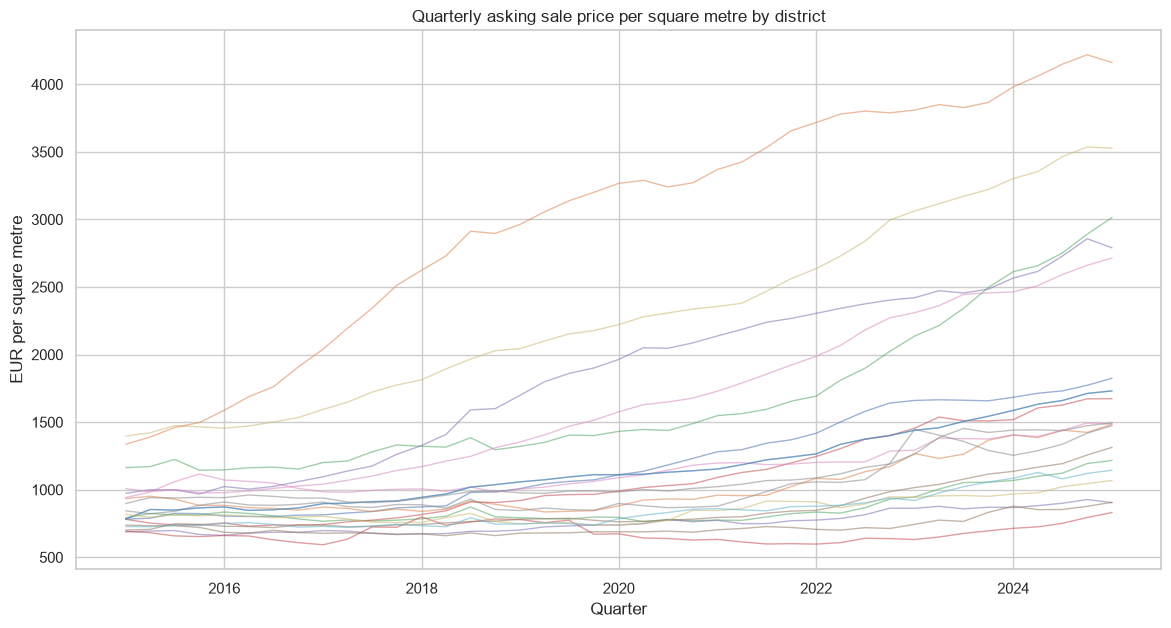

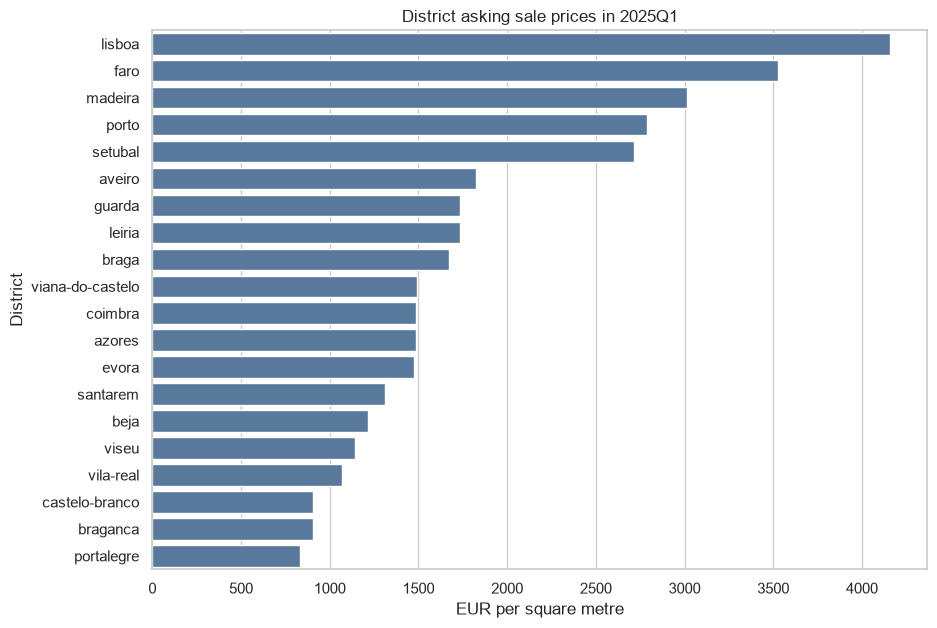

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))
for district, group in panel.groupby('district'):
    ax.plot(group['date'], group['price_sqm_sale'], alpha=0.55, linewidth=1)
ax.set(title='Quarterly asking sale price per square metre by district', xlabel='Quarter', ylabel='EUR per square metre')
plt.show()

latest = panel.loc[panel.groupby('district')['date'].idxmax(), ['district', 'price_sqm_sale']].sort_values('price_sqm_sale', ascending=False)
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=latest, x='price_sqm_sale', y='district', ax=ax, color='#4C78A8')
ax.set(title=f'District asking sale prices in {panel.date.max().to_period("Q")}', xlabel='EUR per square metre', ylabel='District')
plt.show()

### Chart interpretation

Asking sale prices per square metre rise for nearly every district over 2015Q1-2025Q1, but the trajectories fan out rather than move in parallel: Lisboa pulls away from the rest of the country from around 2017 onward, and by 2025Q1 it stands at roughly €4,200/m², clearly above Faro (the second-highest, roughly €3,500/m², about 19% lower) and more than five times the lowest district, Portalegre, which sits well under €1,000/m² throughout the sample. The latest-quarter bar chart shows a clear tier structure: a high-price group (Lisboa, Faro, Madeira, Porto, Setúbal) well above the rest, a mid-price group of mostly northern and central mainland districts, and a low-price group of interior districts (Beja, Viseu, Vila Real, Castelo Branco, Bragança, Portalegre) at the bottom. This cross-sectional spread, not the modest quarter-to-quarter wiggle within a district, is the dominant source of variance in the raw price level - exactly what the district fixed effects in the models below are built to absorb.

### Interpretation

The panel is balanced: all 20 districts are observed in all 41 quarters from 2015Q1 to 2025Q1 (820 rows, no gaps). `price_sqm_sale`/`log_price` have zero missing rows and vary freely across districts within a quarter (up to 19 distinct values per quarter), confirming they are genuine district-level outcomes. `volume_index` and `fdi_real_estate_transactions_meur` also have zero missing rows but only ever take a single value across all districts in a given quarter (`max_unique_within_quarter = 1`), which is the signature of a national common shock rather than a district-varying regressor. `mortgage_rate_fixed` is additionally missing for 300 of 820 rows (it is unavailable before 2019Q1) and is likewise constant within each quarter, so it is a second national series with a shorter available history. None of these three should be read as capturing Lisbon-specific or district-specific exposure - by construction, every district feels the same value of each national series in a given quarter.

## 4. Reproduce baseline models

Specification 1 is the literal baseline: `log_price ~ 1 + EntityEffects + TimeEffects`. The covariate models omit full time fixed effects, so their national FDI, mortgage, and volume coefficients are descriptive associations rather than causal estimates.

In [7]:
model_data = panel.set_index(['district', 'date']).sort_index()
results = {}

def fit_and_store(name, model):
    fitted = model.fit(cov_type='clustered', cluster_entity=True)
    residuals = np.asarray(fitted.resids).reshape(-1)
    results[name] = fitted
    return {
        'n_obs': int(fitted.nobs),
        'r2_total': float(fitted.rsquared),
        'r2_within': float(getattr(fitted, 'rsquared_within', np.nan)),
        'rmse': float(np.sqrt(np.mean(residuals ** 2))),
    }

core = ['log_price', 't', 'volume_index', 'fdi_real_estate_transactions_meur']
if not set(core).issubset(model_data.columns):
    raise KeyError(f'Missing baseline variables: {set(core) - set(model_data.columns)}')

summary = {}
summary['0_pooled_ols'] = fit_and_store('0_pooled_ols', PooledOLS.from_formula(
    'log_price ~ 1 + t + volume_index + fdi_real_estate_transactions_meur',
    data=model_data.dropna(subset=core)
))
summary['0b_entity_fe_only'] = fit_and_store('0b_entity_fe_only', PanelOLS.from_formula(
    'log_price ~ 1 + EntityEffects', data=model_data.dropna(subset=['log_price'])
))
summary['1_twfe_decomposition'] = fit_and_store('1_twfe_decomposition', PanelOLS.from_formula(
    'log_price ~ 1 + EntityEffects + TimeEffects', data=model_data.dropna(subset=['log_price'])
))
summary['2_entity_fe_trend_covars'] = fit_and_store('2_entity_fe_trend_covars', PanelOLS.from_formula(
    'log_price ~ 1 + t + volume_index + fdi_real_estate_transactions_meur + EntityEffects',
    data=model_data.dropna(subset=core)
))

mortgage_cols = core + ['mortgage_rate_fixed']
if 'mortgage_rate_fixed' in model_data.columns:
    summary['3_entity_fe_trend_mortgage_restricted'] = fit_and_store(
        '3_entity_fe_trend_mortgage_restricted',
        PanelOLS.from_formula(
            'log_price ~ 1 + t + volume_index + fdi_real_estate_transactions_meur + mortgage_rate_fixed + EntityEffects',
            data=model_data.dropna(subset=mortgage_cols)
        )
    )

growth_cols = ['price_growth_qoq', 'log_price_lag1', 'volume_index', 'fdi_real_estate_transactions_meur']
summary['5_growth_convergence'] = fit_and_store('5_growth_convergence', PooledOLS.from_formula(
    'price_growth_qoq ~ 1 + log_price_lag1 + volume_index + fdi_real_estate_transactions_meur',
    data=model_data.dropna(subset=growth_cols)
))

comparison = pd.DataFrame(summary).T
display(comparison.round(4))

,n_obs,r2_total,r2_within,rmse
0_pooled_ols,820.0000,0.1990,0.7225,0.3868
0b_entity_fe_only,820.0000,0.0000,0.0000,0.2268
1_twfe_decomposition,820.0000,0.0000,0.0000,0.1170
2_entity_fe_trend_covars,820.0000,0.7225,0.7225,0.1195
3_entity_fe_trend_mortgage_restricted,520.0000,0.8289,0.8289,0.0689
5_growth_convergence,800.0000,0.0647,0.0219,0.0276


### Fit comparison

RMSE falls sharply and monotonically as structure is added, even before any covariate does real work: pooled OLS with only a trend and the two national covariates leaves an RMSE of 0.3868 log points; adding district fixed effects alone (Spec 0b, no covariates) cuts it to 0.2268; adding quarter fixed effects on top (Spec 1, the literal two-way FE baseline) cuts it further to 0.1170. That two-step improvement - first from cross-sectional heterogeneity, then from nationwide time shocks - shows that most of the variation in log price is explained by *which district* and *which quarter* alone, before any economic covariate is introduced. Spec 0b and Spec 1 both report R² of exactly 0.0000 because, once entity (and for Spec 1, time) dummies are the only regressors, `linearmodels` reports the R² of the demeaned model with no covariate left to explain - this 0.0000 is a bookkeeping artifact of a pure absorption specification, not evidence that the fixed effects explain nothing; the RMSE is the correct diagnostic to read here. Spec 2 replaces the quarter dummies with the trend and the two national covariates and recovers R²(within) = 0.7225, identical to the within-R² of pooled Spec 0 - because `t`, `volume_index`, and `fdi_real_estate_transactions_meur` are constant across districts, adding district fixed effects shifts each district's intercept but cannot change their estimated slopes, so Spec 2 is mechanically Spec 0 plus district-specific levels. Spec 3, restricted to 2019Q1-2025Q1 where the mortgage series exists (520 of 820 rows), reaches the best fit of any covariate model (R² = 0.8289, RMSE = 0.0689), but over a shorter and more recent window.

In [8]:
for name, result in results.items():
    print('\n' + '=' * 100)
    print(name)
    print('=' * 100)
    display(result.summary)
    coefficients = pd.concat([
        result.params.rename('coefficient'),
        result.std_errors.rename('std_error'),
        result.tstats.rename('t_stat'),
        result.pvalues.rename('p_value'),
    ], axis=1)
    display(coefficients.round(4))


0_pooled_ols


Dep. Variable:,log_price,R-squared:,0.1990
Estimator:,PooledOLS,R-squared (Between):,0.0000
No. Observations:,820,R-squared (Within):,0.7225
Date:,"Mon, Sep 07 2026",R-squared (Overall):,0.1990
Time:,16:34:41,Log-likelihood,-384.56
Cov. Estimator:,Clustered,,
,,F-statistic:,67.578
Entities:,20,P-value,0.0000
Avg Obs:,41.000,Distribution:,"F(3,816)"
Min Obs:,41.000,,
Max Obs:,41.000,F-statistic (robust):,45.204


,coefficient,std_error,t_stat,p_value
Intercept,6.7878,0.0436,155.6189,0.0000
t,0.0156,0.0020,7.7913,0.0000
volume_index,-0.0010,0.0003,-3.0448,0.0024
fdi_real_estate_transactions_meur,0.0001,0.0000,3.0191,0.0026



0b_entity_fe_only


Dep. Variable:,log_price,R-squared:,0.0000
Estimator:,PanelOLS,R-squared (Between):,0.0000
No. Observations:,820,R-squared (Within):,0.0000
Date:,"Mon, Sep 07 2026",R-squared (Overall):,0.0000
Time:,16:34:41,Log-likelihood,53.106
Cov. Estimator:,Clustered,,
,,F-statistic:,--
Entities:,20,P-value,--
Avg Obs:,41.000,Distribution:,--
Min Obs:,41.000,,
Max Obs:,41.000,F-statistic (robust):,--


...

Dep. Variable:,log_price,R-squared:,0.8289
Estimator:,PanelOLS,R-squared (Between):,0.0000
No. Observations:,520,R-squared (Within):,0.8289
Date:,"Mon, Sep 07 2026",R-squared (Overall):,0.1080
Time:,16:34:41,Log-likelihood,652.94
Cov. Estimator:,Clustered,,
,,F-statistic:,600.93
Entities:,20,P-value,0.0000
Avg Obs:,26.000,Distribution:,"F(4,496)"
Min Obs:,26.000,,
Max Obs:,26.000,F-statistic (robust):,52.213


,coefficient,std_error,t_stat,p_value
Intercept,6.5298,0.0443,147.3441,0.0000
t,0.0180,0.0016,11.4933,0.0000
volume_index,0.0001,0.0001,0.7604,0.4474
fdi_real_estate_transactions_meur,-0.0000,0.0000,-0.7285,0.4666
mortgage_rate_fixed,0.0347,0.0087,3.9785,0.0001



5_growth_convergence


Dep. Variable:,price_growth_qoq,R-squared:,0.0647
Estimator:,PooledOLS,R-squared (Between):,0.6906
No. Observations:,800,R-squared (Within):,0.0219
Date:,"Mon, Sep 07 2026",R-squared (Overall):,0.0647
Time:,16:34:41,Log-likelihood,1738.2
Cov. Estimator:,Clustered,,
,,F-statistic:,18.349
Entities:,20,P-value,0.0000
Avg Obs:,40.000,Distribution:,"F(3,796)"
Min Obs:,40.000,,
Max Obs:,40.000,F-statistic (robust):,13.185


,coefficient,std_error,t_stat,p_value
Intercept,-0.0842,0.0163,-5.1488,0.0000
log_price_lag1,0.0115,0.0019,6.1827,0.0000
volume_index,0.0001,0.0000,2.2438,0.0251
fdi_real_estate_transactions_meur,0.0000,0.0000,1.0425,0.2975


| Specification                                 | Purpose                                                       | Interpretation                                               |
| --------------------------------------------- | ------------------------------------------------------------- | ------------------------------------------------------------ |
| Spec 0: Pooled OLS                            | No fixed effects                                              | Naive benchmark, intentionally weak                          |
| Spec 0b: District FE only                     | Controls for persistent district differences                  | Shows how much price variation is cross-sectional            |
| Spec 1: Two-way FE                            | District and quarter fixed effects                            | Literal baseline and best descriptive decomposition          |
| Spec 2: District FE plus trend and covariates | Estimates coefficients on national series by omitting time FE | Association model, not clean causal identification           |
| Spec 3: Restricted period plus mortgage rate  | Uses 2019Q1 to 2025Q1, when mortgage data exists              | Shorter-sample association model                             |
| Spec 5: Growth-convergence model              | Models price growth with lagged price, volume, and FDI        | Tests whether initially expensive districts grow differently |

### Coefficient interpretation

- **Spec 0 / Spec 2 (identical slopes).** The time trend `t` is positive and highly significant (0.0156 log points per quarter, p < 0.001): nationally, log price per square metre rises by roughly 1.6% per quarter on average over the sample. `volume_index` (INE's national transaction-volume index) is negative and significant (-0.0010, p = 0.0024), and `fdi_real_estate_transactions_meur` is positive and significant (0.0001, p = 0.0026), but both are small relative to the trend and, as national series, describe co-movement with the countrywide price level, not a district-specific response to transaction volume or FDI.
- **Spec 0b / Spec 1.** Both report a near-zero-standard-error intercept with an implausibly large t-statistic (on the order of 10¹⁶). This is a numerical artifact of a model that is pure fixed-effect absorption with no free regressor left after demeaning, not a substantively meaningful result - it should not be quoted as a coefficient in the thesis text.
- **Spec 3 (2019Q1-2025Q1, adds `mortgage_rate_fixed`).** Once the mortgage rate is added and the sample is restricted, `volume_index` (p = 0.4474) and `fdi_real_estate_transactions_meur` (p = 0.4666) both lose significance, while `mortgage_rate_fixed` is positive and significant (0.0347, p < 0.001): quarters with higher fixed mortgage rates are associated with *higher*, not lower, log prices in this window. This is very unlikely to be a causal demand-dampening story; 2021-2023 was a period when rates and prices both rose together nationally (post-pandemic demand and inflation), so this reads as a co-trending association between two national time series, not a locally identified effect of credit conditions on prices.
- **Spec 5 (growth-convergence).** `log_price_lag1` is positive and significant (0.0115, p < 0.001): districts with a higher log price in the previous quarter tend to have *faster*, not slower, subsequent quarterly growth - divergence rather than convergence, the opposite of what the specification's label would suggest. Because Spec 5 is Pooled OLS rather than an entity-effects specification, its R²(between) of 0.6906 (from the printed model summary) dwarfs its R²(within) of 0.0219, meaning this positive relationship is driven almost entirely by persistent cross-district differences - already-expensive coastal/urban districts such as Lisboa and Faro also had higher average growth over the whole decade - rather than a true within-district dynamic. This descriptive divergence pattern is a plausible motivation for the thesis's spatial-inequality question, but it is not a causal, and not even a properly within-district, result as estimated here.

## 5. Diagnostics and thesis writing

The two-way fixed-effects residual is the portion of log price not explained by persistent district differences and nationwide quarterly shocks. This diagnostic does not establish causality.

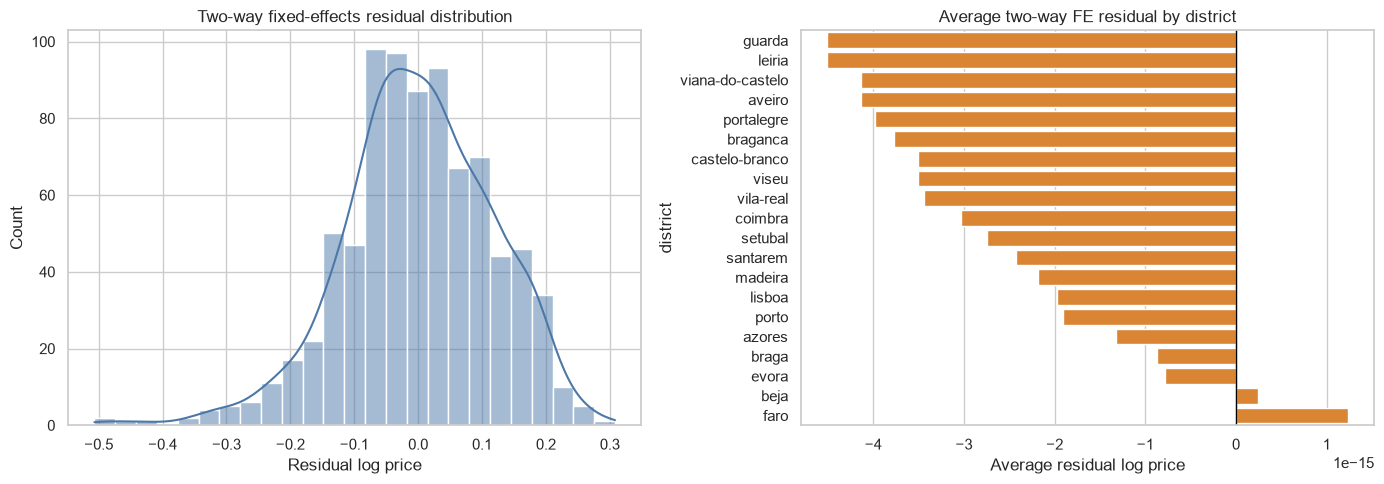

In [9]:
twfe = results['1_twfe_decomposition']
resid = pd.Series(np.asarray(twfe.resids).reshape(-1), index=twfe.resids.index, name='residual').reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(resid['residual'], kde=True, ax=axes[0], color='#4C78A8')
axes[0].set(title='Two-way fixed-effects residual distribution', xlabel='Residual log price')
district_resid = resid.groupby('district', as_index=False)['residual'].mean().sort_values('residual')
sns.barplot(data=district_resid, x='residual', y='district', ax=axes[1], color='#F58518')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set(title='Average two-way FE residual by district', xlabel='Average residual log price')
plt.tight_layout()
plt.show()

### Residual diagnostics

The two-way fixed-effects residual - what remains of log price after removing each district's average level and each quarter's national shock - is unimodal, roughly bell-shaped, and mildly left-skewed, ranging from about -0.5 to +0.3 log points with most of the mass between -0.2 and +0.2. There is no visible multimodality or extreme outlier cluster, which is reassuring for using this residual as a diagnostic baseline. The by-district average-residual chart is essentially zero for every district (values on the order of 10⁻¹⁵), which is expected and mechanical rather than a finding: entity fixed effects remove each district's mean by construction, so the *average* residual within a district cannot differ from zero in a two-way FE model. What would be informative - and is a natural next step rather than something this baseline shows - is the *time pattern* of each district's residual (for example, a Lisbon-specific residual trend around the Golden Visa reform date or a metro opening), since that would isolate a local deviation from the national trend instead of a level difference.

### Thesis-writing template

1. The baseline panel contains **20 districts** and **41 quarters**, covering **2015Q1-2025Q1**, and is fully balanced (820 district-quarter rows, no gaps).
2. Adding quarter fixed effects on top of district fixed effects changes RMSE from **0.2268** (district FE only) to **0.1170** (two-way FE), roughly halving the remaining error. This indicates that nationwide quarterly shocks - the same national price, transaction-volume, FDI, and (from 2019) mortgage-rate series examined above - explain a large share of the price variation left over after accounting for persistent district differences, consistent with a housing market driven substantially by national macro-financial conditions rather than purely local dynamics.
3. District fixed effects indicate large and persistent geographic price differences: pooled OLS alone reaches only R² = 0.1990, but its within-R² of 0.7225 (matched by Spec 2's total R² once district intercepts are added) shows that a district's identity accounts for most of the level differences in price per square metre. District medians range from about €661/m² (Portalegre) to €3,241/m² (Lisboa), with the full sample spanning roughly €593/m² to €4,219/m².
4. FDI (`fdi_real_estate_transactions_meur`), transaction volume (`volume_index`), and the fixed mortgage rate (`mortgage_rate_fixed`) are all **national** time series that take a single value across every district in a given quarter. Their estimated coefficients in Specs 0, 2, and 3 are therefore associations between the national housing price level and other national aggregates over the same period - plausible confounded co-trends, not causal, district-varying, or Lisbon-specific effects. In particular, the positive mortgage-rate coefficient in Spec 3 almost certainly reflects that rates and prices rose together nationally in 2021-2023, not that higher borrowing costs cause higher prices.
5. The next empirical step is a Lisbon-local, time-varying treatment that this district-quarter panel cannot supply: for example, a freguesia-level immigration-exposure measure, foreign-buyer exposure around the Golden Visa reform date, or distance to a dated infrastructure opening (such as a metro extension), combined with a difference-in-differences or event-study design so that treatment intensity varies *within* Lisbon and *within* a quarter - which quarter fixed effects in this baseline would otherwise absorb away entirely.

## Reproducibility
Install dependencies with `pip install -r requirements.txt`, open the notebook from the repository root or `notebooks/`, and run all cells. This notebook reads the cleaned merged dataset and does not depend on exported figures or coefficient tables.